## Recitation 2

In [1]:
import time
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from PIL import Image
from scipy.fft import dctn, idctn
from IPython.display import display

%matplotlib inline

### Problem 2(a)

In [2]:
from sympy import Matrix, Rational

# 带有比值的Matrix矩阵
K = Matrix([[1 for _ in range(4)] for _ in range(4)]) + Matrix.diag(
    [1, 1, 1, 1]
) * Rational(1, 100)
display(K.LUdecomposition()[0])
display(K.LUdecomposition()[1])

Matrix([
[      1,       0,       0, 0],
[100/101,       1,       0, 0],
[100/101, 100/201,       1, 0],
[100/101, 100/201, 100/301, 1]])

Matrix([
[101/100,         1,         1,         1],
[      0, 201/10100,     1/101,     1/101],
[      0,         0, 301/20100,     1/201],
[      0,         0,         0, 401/30100]])

### Problem 6

In [3]:
C4 = la.toeplitz([2, -1, 0, -1])
list(np.linalg.eig(C4))

[array([-6.66133815e-16,  2.00000000e+00,  4.00000000e+00,  2.00000000e+00]),
 array([[ 5.00000000e-01,  7.07106781e-01, -5.00000000e-01,
          5.55111512e-17],
        [ 5.00000000e-01, -2.74466000e-16,  5.00000000e-01,
         -7.07106781e-01],
        [ 5.00000000e-01, -7.07106781e-01, -5.00000000e-01,
          2.58507341e-16],
        [ 5.00000000e-01,  3.08103393e-17,  5.00000000e-01,
          7.07106781e-01]])]

In [4]:
from sympy import Matrix

Matrix(C4).eigenvals()
for eigenval, multiplicity, vectors in Matrix(C4).eigenvects():
    print(f"Eigenvalue: {eigenval}, Multiplicity: {multiplicity}")
    for vector in vectors:
        display(vector)

Eigenvalue: 0, Multiplicity: 1


Matrix([
[1],
[1],
[1],
[1]])

Eigenvalue: 2, Multiplicity: 2


Matrix([
[-1],
[ 0],
[ 1],
[ 0]])

Matrix([
[ 0],
[-1],
[ 0],
[ 1]])

Eigenvalue: 4, Multiplicity: 1


Matrix([
[-1],
[ 1],
[-1],
[ 1]])

### Problem 8

In [5]:
def find_orthonormal_vector(existing_vectors, n, epsilon):
    """Find a vector orthonormal to existing vectors"""
    v = np.random.randn(n)

    for j in range(existing_vectors.shape[1]):
        u = existing_vectors[:, j]
        if np.linalg.norm(u) > epsilon:
            v = v - (v @ u) * u

    norm_v = np.linalg.norm(v)
    if norm_v > epsilon:
        v = v / norm_v
    else:
        for k in range(n):
            v = np.zeros(n)
            v[k] = 1
            for j in range(existing_vectors.shape[1]):
                u = existing_vectors[:, j]
                if np.linalg.norm(u) > epsilon:
                    v = v - (v @ u) * u
            if np.linalg.norm(v) > epsilon:
                v = v / np.linalg.norm(v)
                break

    return v

In [6]:
def complete_orthonormal_basis(V_partial, n, k, epsilon):
    """Complete partial orthonormal matrix to full n x n"""
    V_full = np.eye(n)
    V_full[:, :k] = V_partial[:, :k]

    for i in range(k, n):
        v = V_full[:, i]
        for j in range(i):
            u = V_full[:, j]
            v = v - (v @ u) * u

        norm_v = np.linalg.norm(v)
        if norm_v > epsilon:
            V_full[:, i] = v / norm_v
        else:
            v = np.random.randn(n)
            for j in range(i):
                u = V_full[:, j]
                v = v - (v @ u) * u
            V_full[:, i] = v / np.linalg.norm(v)

    return V_full

In [7]:
def compute_eigen_decomposition(M, epsilon, max_iter):
    """
    Compute all eigenvalues and eigenvectors using power iteration with deflation
    """
    n = M.shape[0]
    eigenvalues = np.zeros(n)
    eigenvectors = np.zeros((n, n))

    M_deflated = M.copy()

    for i in range(n):
        # Power iteration
        v = np.random.randn(n)
        v = v / np.linalg.norm(v)

        for _ in range(max_iter):
            v_new = M_deflated @ v
            norm_v = np.linalg.norm(v_new)

            if norm_v < epsilon:
                eigenvalues[i] = 0
                v = find_orthonormal_vector(eigenvectors[:, :i], n, epsilon)
                break

            v_new = v_new / norm_v

            # Check convergence
            if (
                np.linalg.norm(v_new - v) < epsilon
                or np.linalg.norm(v_new + v) < epsilon
            ):
                v = v_new
                break

            v = v_new

        # Rayleigh quotient for eigenvalue
        eigenvalues[i] = (v @ M_deflated @ v) / (v @ v)
        eigenvectors[:, i] = v

        # Deflation
        M_deflated = M_deflated - eigenvalues[i] * np.outer(v, v)

    return eigenvalues, eigenvectors

In [8]:
def svd_factorization(A, epsilon=1e-10, max_iter=1000):
    """
    Compute SVD factorization A = U * Σ * V^T

    Parameters:
    -----------
    A : numpy array of shape (m, n)
    epsilon : convergence threshold
    max_iter : maximum iterations for power method

    Returns:
    --------
    U : m x m orthogonal matrix
    S : vector of singular values (length min(m,n))
    Vt : n x n orthogonal matrix (V transpose)
    """
    m, n = A.shape

    # Compute A^T * A (n x n) and A * A^T (m x m)
    AtA = A.T @ A
    AAt = A @ A.T

    # Determine which matrix is smaller for efficiency
    if m <= n:
        # Use A * A^T (m x m) to find left singular vectors U first
        eigenvalues_U, U = compute_eigen_decomposition(AAt, epsilon, max_iter)

        # Singular values are square roots of eigenvalues
        S = np.sqrt(np.maximum(eigenvalues_U, 0))

        # Sort in descending order
        idx = np.argsort(S)[::-1]
        S = S[idx]
        U = U[:, idx]

        # Compute V: v_i = (A^T * u_i) / sigma_i
        V = np.zeros((n, m))
        for i in range(m):
            if S[i] > epsilon:
                V[:, i] = (A.T @ U[:, i]) / S[i]

        # Complete V to n x n orthonormal basis
        if n > m:
            V = complete_orthonormal_basis(V, n, m, epsilon)

        Vt = V.T

    else:
        # Use A^T * A (n x n) to find right singular vectors V first
        eigenvalues_V, V = compute_eigen_decomposition(AtA, epsilon, max_iter)

        # Singular values
        S = np.sqrt(np.maximum(eigenvalues_V, 0))

        # Sort in descending order
        idx = np.argsort(S)[::-1]
        S = S[idx]
        V = V[:, idx]

        # Compute U: u_i = (A * v_i) / sigma_i
        U = np.zeros((m, n))
        for i in range(n):
            if S[i] > epsilon:
                U[:, i] = (A @ V[:, i]) / S[i]

        # Complete U to m x m orthonormal matrix
        if m > n:
            U = complete_orthonormal_basis(U, m, n, epsilon)

        Vt = V.T

    return U, S, Vt

In [9]:
np.random.seed(42)
print("Test 1: Square matrix (4x4)")
A1 = np.random.randn(4, 4)
U, S, Vt = svd_factorization(A1)
print(f"Singular values: {S}")
A1_reconstructed = U @ np.diag(S) @ Vt
print(f"Reconstruction error: {np.linalg.norm(A1 - A1_reconstructed):.2e}")

Test 1: Square matrix (4x4)
Singular values: [3.07958938 1.9255234  0.91998798 0.34164905]
Reconstruction error: 3.68e-10


In [10]:
print("\nTest 2: Tall matrix (5x3)")
A2 = np.random.randn(5, 3)
U2, S2, Vt2 = svd_factorization(A2)
S2_mat = np.zeros((5, 3))
S2_mat[:3, :3] = np.diag(S2)
A2_reconstructed = U2 @ S2_mat @ Vt2
print(f"Reconstruction error: {np.linalg.norm(A2 - A2_reconstructed):.2e}")


Test 2: Tall matrix (5x3)
Reconstruction error: 2.39e-10


In [11]:
print("\nTest 3: Wide matrix (3x5)")
A3 = np.random.randn(3, 5)
U3, S3, Vt3 = svd_factorization(A3)
S3_mat = np.zeros((3, 5))
S3_mat[:3, :3] = np.diag(S3)
A3_reconstructed = U3 @ S3_mat @ Vt3
print(f"Reconstruction error: {np.linalg.norm(A3 - A3_reconstructed):.2e}")


Test 3: Wide matrix (3x5)
Reconstruction error: 1.84e-10


### Problem 9

> Image Compression using SVD (Big Tiger)

This section implements image compression using Singular Value Decomposition (SVD).

Steps:
1. Load the RGB image
2. Convert to grayscale using NTSC formula
3. Compute storage size
4. Perform SVD
5. Plot singular values
6. Reconstruct compressed images
7. Compute compression ratio

#### Load image and convert to grayscale

Image shape: (818, 837, 3)
Grayscale shape: (818, 837)


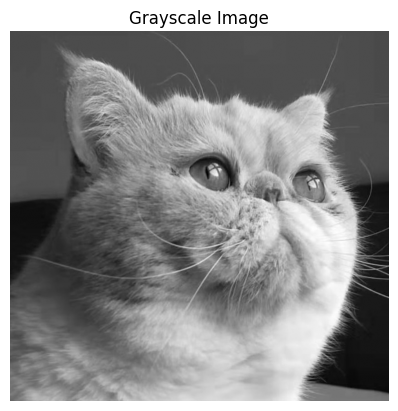

In [12]:
img = Image.open("../res/bigtiger.jpeg")
img_array = np.array(img)

m, n, _ = img_array.shape
print("Image shape:", img_array.shape)

# Convert RGB to grayscale using NTSC formula
gray = (
    0.299 * img_array[:, :, 0] + 0.587 * img_array[:, :, 1] + 0.114 * img_array[:, :, 2]
)

print("Grayscale shape:", gray.shape)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

#### Storage size calculation

In [13]:
# Storage size
pixels = gray.size

# float64 storage
size_bytes_float = pixels * 8
size_MB_float = size_bytes_float / (1024**2)

# uint8 storage
size_bytes_uint8 = pixels * 1
size_MB_uint8 = size_bytes_uint8 / (1024**2)

print("Pixels:", pixels)
print("Storage (float64):", size_MB_float, "MB")
print("Storage (uint8):", size_MB_uint8, "MB")

Pixels: 684666
Storage (float64): 5.2235870361328125 MB
Storage (uint8): 0.6529483795166016 MB


#### Compute SVD

In [14]:
U, S, Vt = np.linalg.svd(gray, full_matrices=False)

print("Rank of matrix:", np.linalg.matrix_rank(gray))

Rank of matrix: 818


#### Plot singular values

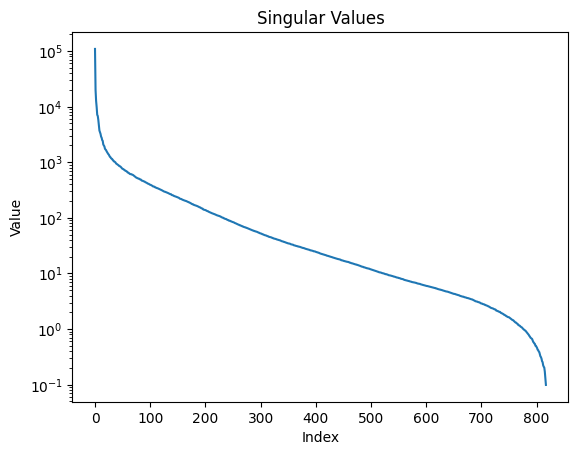

In [15]:
plt.figure()
plt.plot(S)
plt.title("Singular Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.yscale("log")
plt.show()

#### Image reconstruction using rank-k approximation

In [16]:
def reconstruct(k):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    V_k = Vt[:k, :]
    return U_k @ S_k @ V_k

#### Compare different k values

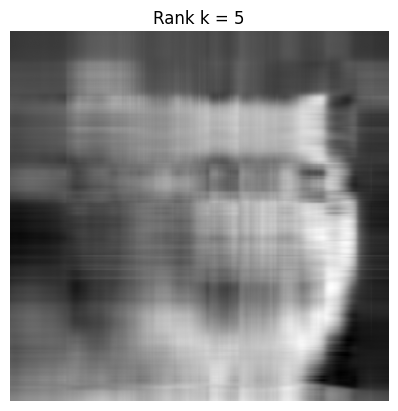

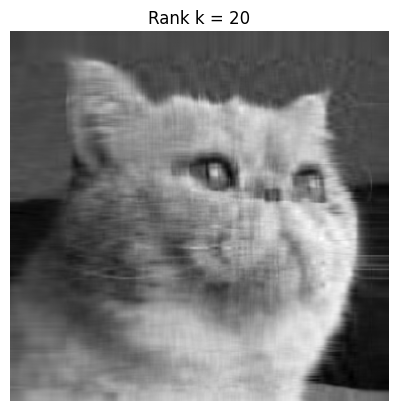

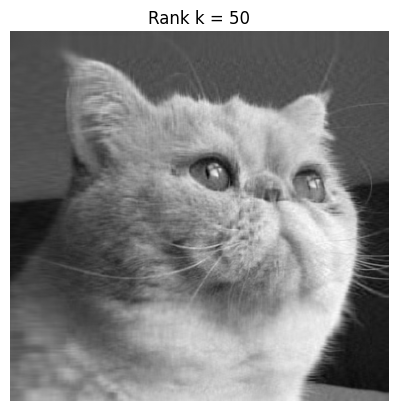

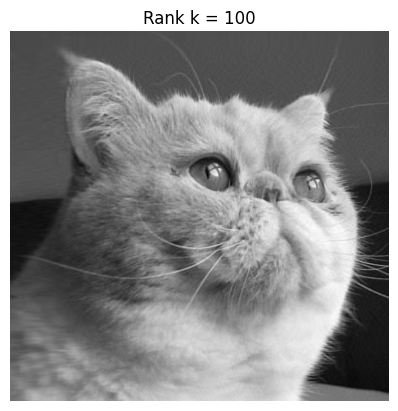

In [17]:
k_values = [5, 20, 50, 100]

for k in k_values:
    A_k = reconstruct(k)
    plt.figure()
    plt.imshow(A_k, cmap="gray")
    plt.title(f"Rank k = {k}")
    plt.axis("off")
    plt.show()

#### Compression ratio

In [18]:
k = 50

# Calculate sizes in terms of number of elements
original_size = m * n
compressed_size = k * (m + n + 1)  # U_k: m×k, S_k: k, V_k: k×n

# Calculate actual storage in bytes (assuming float64)
original_bytes = original_size * 8
compressed_bytes = compressed_size * 8

# Calculate sizes in MB
original_MB = original_bytes / (1024**2)
compressed_MB = compressed_bytes / (1024**2)

# Calculate percentages
compression_ratio = original_size / compressed_size
space_used_percent = (compressed_size / original_size) * 100
space_saved_percent = 100 - space_used_percent

print("=" * 50)
print("Storage Space Comparison (k={})".format(k))
print("=" * 50)
print("\nOriginal Image:")
print(f"  Elements: {original_size:,}")
print(f"  Storage: {original_MB:.2f} MB")
print("\nCompressed (SVD):")
print(f"  Elements: {compressed_size:,}")
print(f"  Storage: {compressed_MB:.2f} MB")
print("\nCompression Metrics:")
print(f"  Compression Ratio: {compression_ratio:.2f}x")
print(f"  Space Used: {space_used_percent:.2f}%")
print(f"  Space Saved: {space_saved_percent:.2f}%")
print(f"  Saved: {original_MB - compressed_MB:.2f} MB")
print("=" * 50)

Storage Space Comparison (k=50)

Original Image:
  Elements: 684,666
  Storage: 5.22 MB

Compressed (SVD):
  Elements: 82,800
  Storage: 0.63 MB

Compression Metrics:
  Compression Ratio: 8.27x
  Space Used: 12.09%
  Space Saved: 87.91%
  Saved: 4.59 MB


### Problem 9 (Optional)

> Compressed Sensing for Image Reconstruction

This section implements compressed sensing reconstruction of the Big Tiger image using sparse observations.

We reconstruct the image from randomly sampled pixels using:

1. **L2 regularization (Ridge regression)**: $\underset{\mathbf s}\argmin ||C\Psi \mathbf s-\mathbf y||^2 + \lambda||\mathbf s||_2^2$
2. **L1 regularization (Lasso/ISTA)**: $\underset{\mathbf s}\argmin ||C\Psi \mathbf s-\mathbf y||^2 + \lambda||\mathbf s||_1$

where:
- $\mathbf s$ is the unknown DCT coefficients
- $C$ is the sampling matrix
- $\mathbf y$ is the downsampled image

#### Load Image and Convert to Grayscale

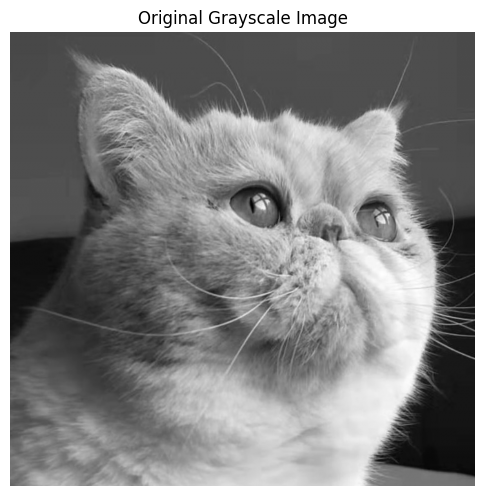

Image size: 818 x 837 = 684666 pixels


In [19]:
img = Image.open("../res/bigtiger.jpeg").convert("L")
img_array = np.array(img).astype(np.float32) / 255.0

plt.figure(figsize=(6, 6))
plt.imshow(img_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

h, w = img_array.shape
N = h * w
print(f"Image size: {h} x {w} = {N} pixels")

#### Define DCT Functions

In [20]:
def dct2(x):
    return dctn(x, norm="ortho")


def idct2(x):
    return idctn(x, norm="ortho")

#### Define Compressed Sensing Operators

In [21]:
class CSOperator:
    def __init__(self, shape, idx):
        self.h, self.w = shape
        self.N = self.h * self.w
        self.idx = idx

    def A(self, s):
        img = idct2(s.reshape(self.h, self.w))
        x = img.reshape(-1)
        return x[self.idx]

    def AT(self, r):
        x = np.zeros(self.N, dtype=np.float64)
        x[self.idx] = r
        img = x.reshape(self.h, self.w)
        s = dct2(img)
        return s.reshape(-1)

#### Random Pixel Sampling

In [22]:
sampling_rates = [0.1, 0.05, 0.01]
x = img_array.flatten()

print("Sampling rates to test:", sampling_rates)
for rate in sampling_rates:
    num_samples = int(N * rate)
    print(f"  {rate * 100:.0f}%: {num_samples} samples out of {N}")

Sampling rates to test: [0.1, 0.05, 0.01]
  10%: 68466 samples out of 684666
  5%: 34233 samples out of 684666
  1%: 6846 samples out of 684666


#### L2 Regularization (Ridge Regression)

In [23]:
def ridge_gradient_descent(op, y, lam=0.01, max_iter=100, step=0.5):
    s = np.zeros(op.N, dtype=np.float64)
    for i in range(max_iter):
        residual = op.A(s) - y
        grad = op.AT(residual) + 2 * lam * s
        s = s - step * grad
        if i % 20 == 0:
            loss = 0.5 * np.sum(residual**2) + lam * np.sum(s**2)
            print(f"  Iter {i}: loss = {loss:.6f}")
    return s

#### L1 Regularization (ISTA Algorithm)

In [24]:
def soft_threshold(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)


def ista(op, y, lam=0.01, step=1.0, max_iter=100):
    s = np.zeros(op.N, dtype=np.float64)
    for i in range(max_iter):
        residual = op.A(s) - y
        grad = op.AT(residual)
        s = s - step * grad
        s = soft_threshold(s, lam * step)
        if i % 20 == 0:
            loss = 0.5 * np.sum(residual**2) + lam * np.sum(np.abs(s))
            print(f"  Iter {i}: loss = {loss:.6f}")
    return s

#### Run Reconstruction with 10% Sampling

In [25]:
sampling_rate = 0.1
m = int(N * sampling_rate)

np.random.seed(42)
idx = np.random.choice(N, m, replace=False)
y = x[idx]

print(f"Sampling rate: {sampling_rate * 100}%")
print(f"Number of samples: {m} out of {N}")

op = CSOperator((h, w), idx)

Sampling rate: 10.0%
Number of samples: 68466 out of 684666


#### L2 Reconstruction

In [26]:
print("Running L2 (Ridge) reconstruction...")
start_time = time.time()
s_l2 = ridge_gradient_descent(op, y, lam=0.001, max_iter=600, step=0.5)
recon_l2 = idct2(s_l2.reshape(h, w))
l2_time = time.time() - start_time
print(f"L2 reconstruction time: {l2_time:.2f} seconds")

Running L2 (Ridge) reconstruction...
  Iter 0: loss = 9911.820183
  Iter 20: loss = 19.774203
  Iter 40: loss = 19.774185
  Iter 60: loss = 19.774185
  Iter 80: loss = 19.774185
  Iter 100: loss = 19.774185
  Iter 120: loss = 19.774185
  Iter 140: loss = 19.774185
  Iter 160: loss = 19.774185
  Iter 180: loss = 19.774185
  Iter 200: loss = 19.774185
  Iter 220: loss = 19.774185
  Iter 240: loss = 19.774185
  Iter 260: loss = 19.774185
  Iter 280: loss = 19.774185
  Iter 300: loss = 19.774185
  Iter 320: loss = 19.774185
  Iter 340: loss = 19.774185
  Iter 360: loss = 19.774185
  Iter 380: loss = 19.774185
  Iter 400: loss = 19.774185
  Iter 420: loss = 19.774185
  Iter 440: loss = 19.774185
  Iter 460: loss = 19.774185
  Iter 480: loss = 19.774185
  Iter 500: loss = 19.774185
  Iter 520: loss = 19.774185
  Iter 540: loss = 19.774185
  Iter 560: loss = 19.774185
  Iter 580: loss = 19.774185
L2 reconstruction time: 36.50 seconds


#### L1 Reconstruction

In [27]:
print("\nRunning L1 (ISTA) reconstruction...")
start_time = time.time()
s_l1 = ista(op, y, lam=0.01, step=1.0, max_iter=1000)
recon_l1 = idct2(s_l1.reshape(h, w))
l1_time = time.time() - start_time
print(f"L1 reconstruction time: {l1_time:.2f} seconds")


Running L1 (ISTA) reconstruction...
  Iter 0: loss = 10724.111366
  Iter 20: loss = 603.828299
  Iter 40: loss = 507.957401
  Iter 60: loss = 444.782977
  Iter 80: loss = 395.856932
  Iter 100: loss = 355.006011
  Iter 120: loss = 319.329851
  Iter 140: loss = 287.334721
  Iter 160: loss = 258.113067
  Iter 180: loss = 231.203593
  Iter 200: loss = 206.291684
  Iter 220: loss = 183.211426
  Iter 240: loss = 161.875590
  Iter 260: loss = 142.293377
  Iter 280: loss = 124.498400
  Iter 300: loss = 108.613909
  Iter 320: loss = 94.809874
  Iter 340: loss = 83.336355
  Iter 360: loss = 74.485207
  Iter 380: loss = 68.278741
  Iter 400: loss = 64.378791
  Iter 420: loss = 62.231410
  Iter 440: loss = 61.145271
  Iter 460: loss = 60.618348
  Iter 480: loss = 60.361039
  Iter 500: loss = 60.231019
  Iter 520: loss = 60.163023
  Iter 540: loss = 60.126013
  Iter 560: loss = 60.105077
  Iter 580: loss = 60.092785
  Iter 600: loss = 60.085361
  Iter 620: loss = 60.080772
  Iter 640: loss = 60.0

#### Compare Results (10% Sampling)

In [28]:
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(1.0 / np.sqrt(mse))


psnr_l2 = psnr(img_array, recon_l2)
psnr_l1 = psnr(img_array, recon_l1)

print(f"L2 Reconstruction PSNR: {psnr_l2:.2f} dB")
print(f"L1 Reconstruction PSNR: {psnr_l1:.2f} dB")

nonzero_l2 = np.sum(np.abs(s_l2) > 1e-10)
nonzero_l1 = np.sum(np.abs(s_l1) > 1e-10)
print("\nNon-zero DCT coefficients:")
print(f"  L2: {nonzero_l2} / {N} ({100 * nonzero_l2 / N:.1f}%)")
print(f"  L1: {nonzero_l1} / {N} ({100 * nonzero_l1 / N:.1f}%)")

L2 Reconstruction PSNR: 5.88 dB
L1 Reconstruction PSNR: 28.65 dB

Non-zero DCT coefficients:
  L2: 684666 / 684666 (100.0%)
  L1: 40391 / 684666 (5.9%)


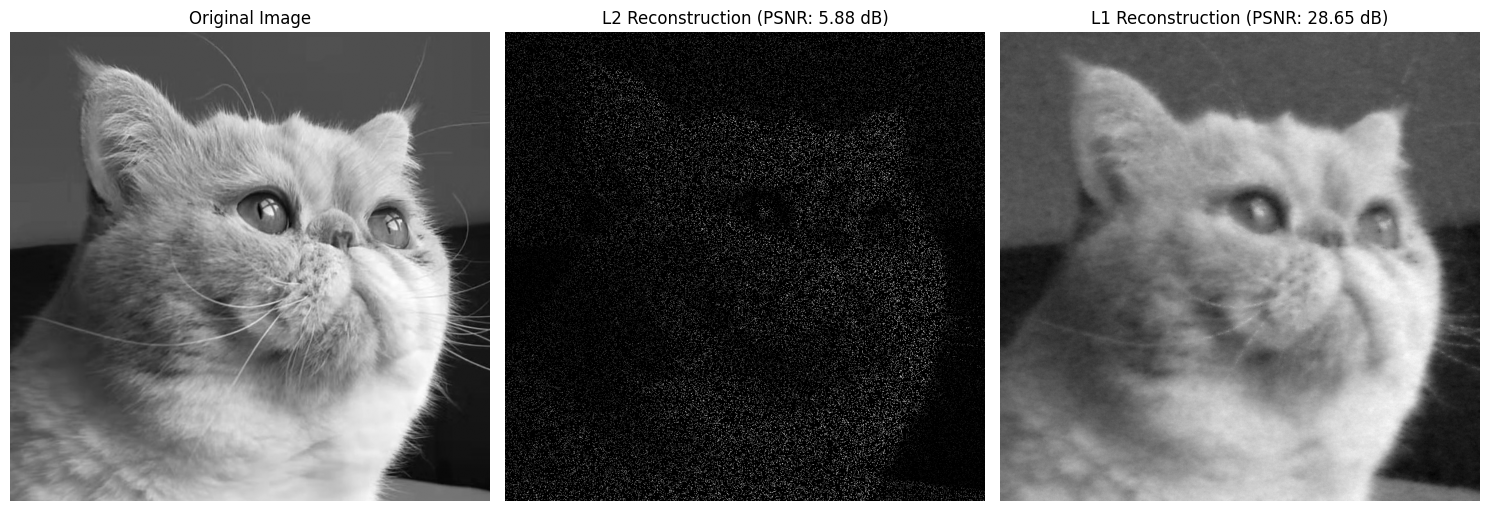

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(recon_l2, cmap="gray")
plt.title(f"L2 Reconstruction (PSNR: {psnr_l2:.2f} dB)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(recon_l1, cmap="gray")
plt.title(f"L1 Reconstruction (PSNR: {psnr_l1:.2f} dB)")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Run Reconstruction with 1% Sampling

In [30]:
sampling_rate = 0.01
m = int(N * sampling_rate)

np.random.seed(42)
idx = np.random.choice(N, m, replace=False)
y = x[idx]

print(f"Sampling rate: {sampling_rate * 100}%")
print(f"Number of samples: {m} out of {N}")

op = CSOperator((h, w), idx)

Sampling rate: 1.0%
Number of samples: 6846 out of 684666


In [31]:
print("\nRunning L2 (Ridge) reconstruction...")
s_l2 = ridge_gradient_descent(op, y, lam=0.001, max_iter=100, step=0.5)
recon_l2 = idct2(s_l2.reshape(h, w))

print("\nRunning L1 (ISTA) reconstruction...")
s_l1 = ista(op, y, lam=0.01, step=1.0, max_iter=600)
recon_l1 = idct2(s_l1.reshape(h, w))


Running L2 (Ridge) reconstruction...
  Iter 0: loss = 1003.642307
  Iter 20: loss = 2.002279
  Iter 40: loss = 2.002277
  Iter 60: loss = 2.002277
  Iter 80: loss = 2.002277

Running L1 (ISTA) reconstruction...
  Iter 0: loss = 1234.132635
  Iter 20: loss = 173.037438
  Iter 40: loss = 155.679565
  Iter 60: loss = 145.911409
  Iter 80: loss = 139.055111
  Iter 100: loss = 133.693214
  Iter 120: loss = 129.227338
  Iter 140: loss = 125.358463
  Iter 160: loss = 121.929057
  Iter 180: loss = 118.828744
  Iter 200: loss = 115.984254
  Iter 220: loss = 113.348771
  Iter 240: loss = 110.879534
  Iter 260: loss = 108.548213
  Iter 280: loss = 106.335835
  Iter 300: loss = 104.226348
  Iter 320: loss = 102.210418
  Iter 340: loss = 100.273122
  Iter 360: loss = 98.405315
  Iter 380: loss = 96.595638
  Iter 400: loss = 94.839720
  Iter 420: loss = 93.133416
  Iter 440: loss = 91.474866
  Iter 460: loss = 89.860269
  Iter 480: loss = 88.288279
  Iter 500: loss = 86.754650
  Iter 520: loss = 85

In [32]:
psnr_l2 = psnr(img_array, recon_l2)
psnr_l1 = psnr(img_array, recon_l1)

print(f"L2 Reconstruction PSNR: {psnr_l2:.2f} dB")
print(f"L1 Reconstruction PSNR: {psnr_l1:.2f} dB")

nonzero_l2 = np.sum(np.abs(s_l2) > 1e-10)
nonzero_l1 = np.sum(np.abs(s_l1) > 1e-10)
print("\nNon-zero DCT coefficients:")
print(f"  L2: {nonzero_l2} / {N} ({100 * nonzero_l2 / N:.1f}%)")
print(f"  L1: {nonzero_l1} / {N} ({100 * nonzero_l1 / N:.1f}%)")

L2 Reconstruction PSNR: 5.46 dB
L1 Reconstruction PSNR: 9.44 dB

Non-zero DCT coefficients:
  L2: 684666 / 684666 (100.0%)
  L1: 14015 / 684666 (2.0%)


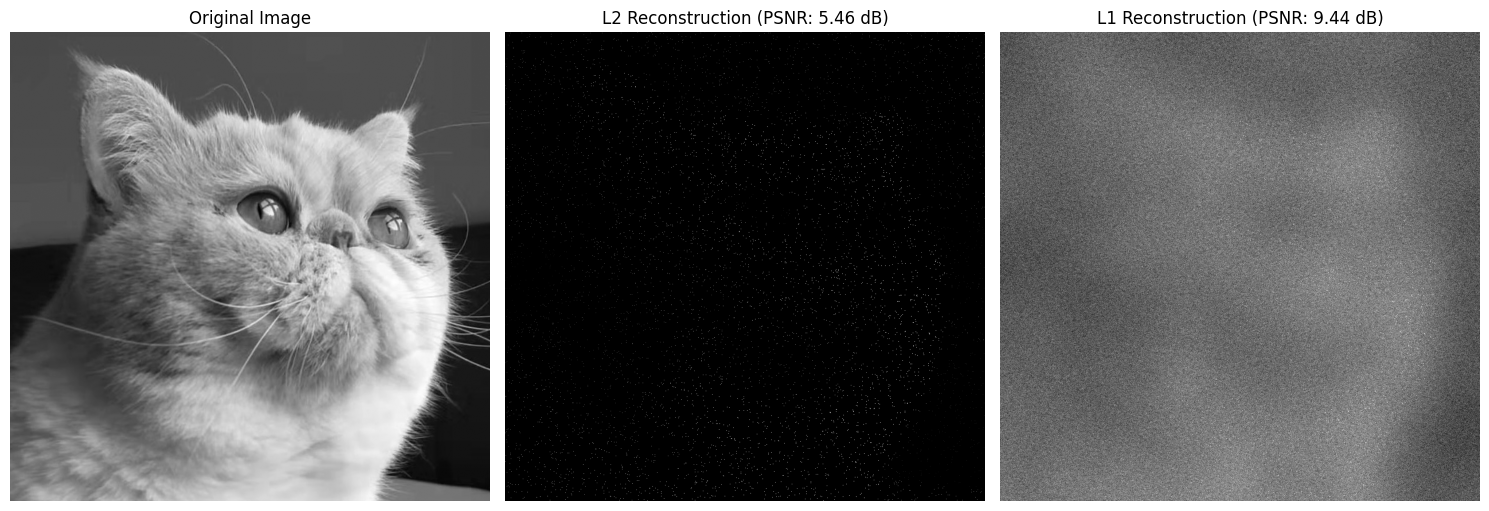

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(recon_l2, cmap="gray")
plt.title(f"L2 Reconstruction (PSNR: {psnr_l2:.2f} dB)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(recon_l1, cmap="gray")
plt.title(f"L1 Reconstruction (PSNR: {psnr_l1:.2f} dB)")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Visualize DCT Coefficient Sparsity

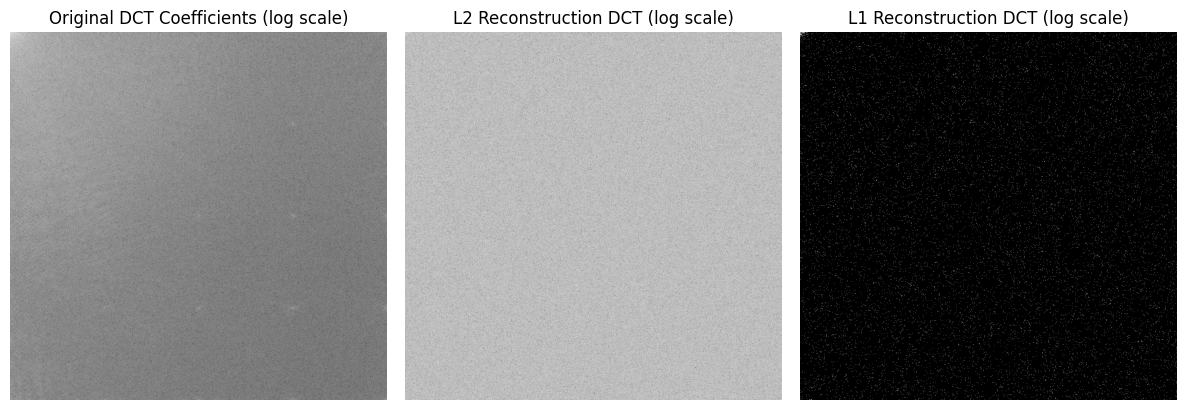

In [34]:
S_true = dct2(img_array)
s_true = S_true.flatten()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.log10(np.abs(S_true) + 1e-10), cmap="gray")
plt.title("Original DCT Coefficients (log scale)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.log10(np.abs(s_l2.reshape(h, w)) + 1e-10), cmap="gray")
plt.title("L2 Reconstruction DCT (log scale)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.log10(np.abs(s_l1.reshape(h, w)) + 1e-10), cmap="gray")
plt.title("L1 Reconstruction DCT (log scale)")
plt.axis("off")

plt.tight_layout()
plt.show()

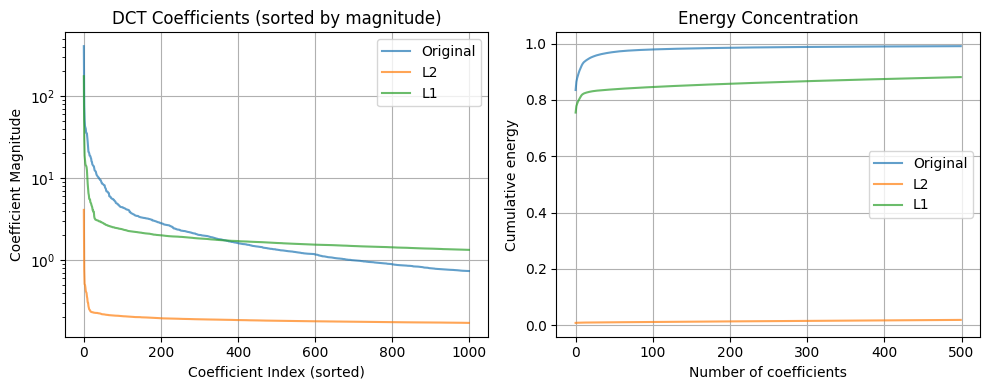

In [35]:
s_sorted = np.sort(np.abs(s_true))[::-1]
s_l2_sorted = np.sort(np.abs(s_l2))[::-1]
s_l1_sorted = np.sort(np.abs(s_l1))[::-1]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.semilogy(s_sorted[:1000], label="Original", alpha=0.7)
plt.semilogy(s_l2_sorted[:1000], label="L2", alpha=0.7)
plt.semilogy(s_l1_sorted[:1000], label="L1", alpha=0.7)
plt.xlabel("Coefficient Index (sorted)")
plt.ylabel("Coefficient Magnitude")
plt.title("DCT Coefficients (sorted by magnitude)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
cumsum_true = np.cumsum(s_sorted**2) / np.sum(s_sorted**2)
cumsum_l2 = np.cumsum(s_l2_sorted**2) / np.sum(s_l2_sorted**2)
cumsum_l1 = np.cumsum(s_l1_sorted**2) / np.sum(s_l1_sorted**2)
plt.plot(cumsum_true[:500], label="Original", alpha=0.7)
plt.plot(cumsum_l2[:500], label="L2", alpha=0.7)
plt.plot(cumsum_l1[:500], label="L1", alpha=0.7)
plt.xlabel("Number of coefficients")
plt.ylabel("Cumulative energy")
plt.title("Energy Concentration")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()